In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('raw_video_data.csv')
df

,Unnamed: 0,Title,Published_date,Views,Likes,Comments
0,0,DAX in Power BI,2026-05-22T12:42:39Z,5149,178,0
1,1,2026 FREE Data Analyst Bootcamp [24 Hours+] fo...,2026-05-19T12:30:29Z,118538,8737,454
2,2,Should You Take Google's AI Certificate? My Ho...,2026-05-11T15:00:58Z,9442,327,21
3,3,Switching to Mac after 10 years as a Microsoft...,2026-05-05T12:01:35Z,5422,211,71
4,4,Learn ETL Pipelines in Databricks in Under 1 H...,2026-04-28T12:00:57Z,11482,366,9
...,...,...,...,...,...,...
436,436,Data Analyst Resume | Reviewing My Resume! | F...,2020-01-30T14:07:55Z,88044,1839,63
437,437,Working at a Big Company Vs Small Company | To...,2020-01-25T16:38:39Z,16455,443,23
438,438,Data Analyst Salary | 100k with No Experience,2020-01-23T03:16:09Z,66895,2256,217
439,439,Truth About Big Companies | Told by a Fortune ...,2020-01-21T03:52:15Z,10421,375,22


In [3]:
df = df.drop(columns="Unnamed: 0")
# 1. Convert to datetime object
df['Published_date'] = pd.to_datetime(df['Published_date'])

# 2. Extract Temporal Features
df['Year_Published'] = df['Published_date'].dt.year
df['Month_Published'] = df['Published_date'].dt.month
df['Day_of_Week'] = df['Published_date'].dt.day_name()
df['Hour_of_Day'] = df['Published_date'].dt.hour

# 3. Engagement Metrics
df['Like_Rate_%'] = (df['Likes'] / df['Views']) * 100
df['Comment_Rate_%'] = (df['Comments'] / df['Views']) * 100

# 4. Title Length Analysis
df['Title_Length'] = df['Title'].apply(len)
df

,Title,Published_date,Views,Likes,Comments,Year_Published,Month_Published,Day_of_Week,Hour_of_Day,Like_Rate_%,Comment_Rate_%,Title_Length
0,DAX in Power BI,2026-05-22 12:42:39+00:00,5149,178,0,2026,5,Friday,12,3.456982,0.000000,15
1,2026 FREE Data Analyst Bootcamp [24 Hours+] fo...,2026-05-19 12:30:29+00:00,118538,8737,454,2026,5,Tuesday,12,7.370632,0.383000,96
2,Should You Take Google's AI Certificate? My Ho...,2026-05-11 15:00:58+00:00,9442,327,21,2026,5,Monday,15,3.463249,0.222411,55
3,Switching to Mac after 10 years as a Microsoft...,2026-05-05 12:01:35+00:00,5422,211,71,2026,5,Tuesday,12,3.891553,1.309480,51
4,Learn ETL Pipelines in Databricks in Under 1 H...,2026-04-28 12:00:57+00:00,11482,366,9,2026,4,Tuesday,12,3.187598,0.078384,82
...,...,...,...,...,...,...,...,...,...,...,...,...
436,Data Analyst Resume | Reviewing My Resume! | F...,2020-01-30 14:07:55+00:00,88044,1839,63,2020,1,Thursday,14,2.088728,0.071555,69
437,Working at a Big Company Vs Small Company | To...,2020-01-25 16:38:39+00:00,16455,443,23,2020,1,Saturday,16,2.692191,0.139775,78
438,Data Analyst Salary | 100k with No Experience,2020-01-23 03:16:09+00:00,66895,2256,217,2020,1,Thursday,3,3.372449,0.324389,45
439,Truth About Big Companies | Told by a Fortune ...,2020-01-21 03:52:15+00:00,10421,375,22,2020,1,Tuesday,3,3.598503,0.211112,62


**Video Upload Counts by Day and Hour (UTC)**

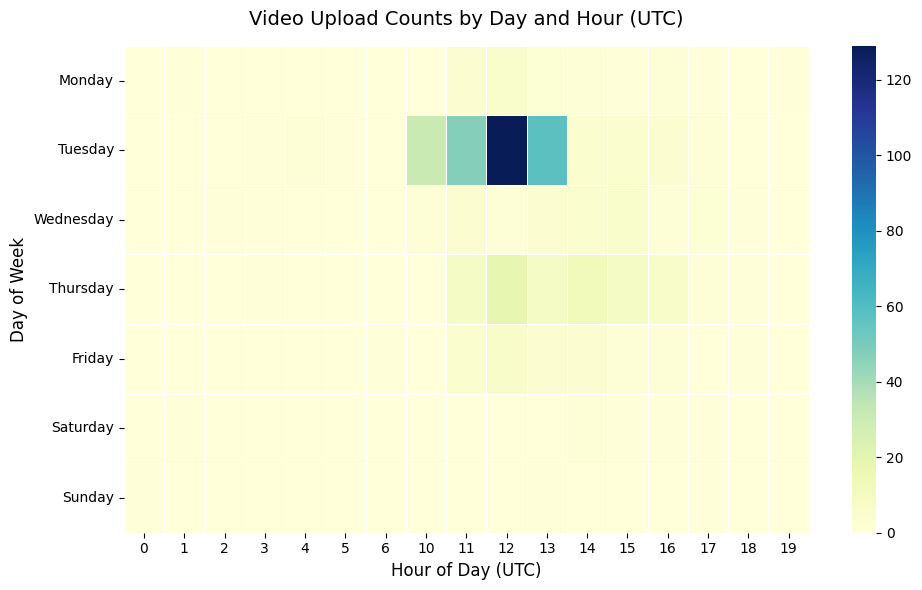

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
freq_day_hour = df.groupby(["Day_of_Week", "Hour_of_Day"]).size()
heatmap_data = freq_day_hour.unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(["Monday", "Tuesday", "Wednesday", 
                      "Thursday", "Friday","Saturday", 
                      "Sunday",])
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, fmt="d", linewidths=0.5)

plt.title("Video Upload Counts by Day and Hour (UTC)", fontsize=14, pad=15)
plt.xlabel("Hour of Day (UTC)", fontsize=12)
plt.ylabel("Day of Week", fontsize=12)
plt.tight_layout()

plt.show()


**Video Performance - 3D View**

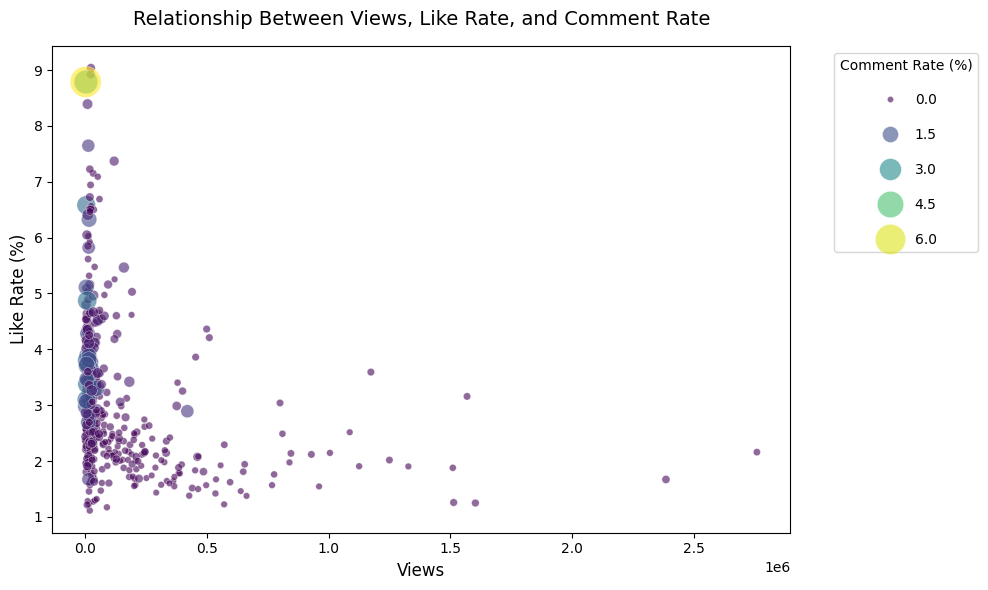

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Views", y="Like_Rate_%", 
                size="Comment_Rate_%", sizes=(20,500), 
                hue="Comment_Rate_%", alpha=0.6, palette="viridis")

plt.title("Relationship Between Views, Like Rate, and Comment Rate", fontsize=14, pad=15)
plt.xlabel("Views", fontsize=12)
plt.ylabel("Like Rate (%)", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1),loc="upper left",title="Comment Rate (%)", labelspacing=1.5)

plt.tight_layout()
plt.show()

**Growth Trajectory of Channel**

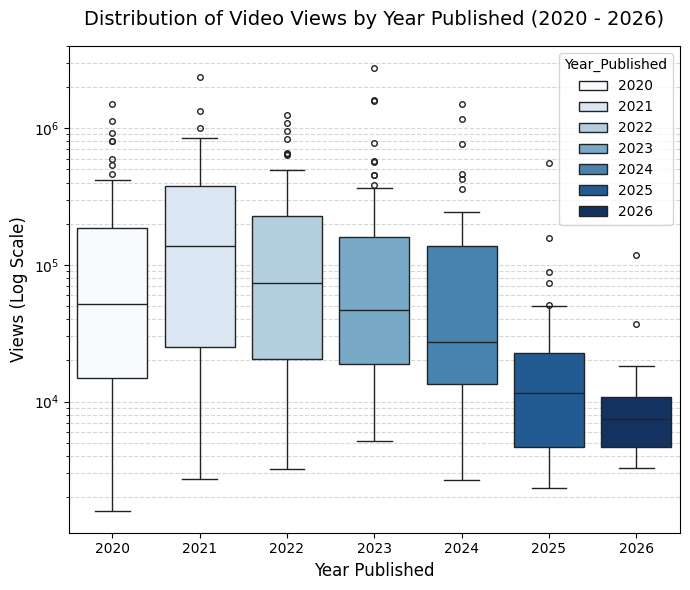

In [6]:
# 1. Set the figure size for optimal clarity
plt.figure(figsize=(7, 6))

# 2. Ensure the X-axis handles years chronologically from 2020 to 2026
years_order = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

# 3. Create the boxplot
sns.boxplot(
    data=df,
    x="Year_Published",
    y="Views",
    hue="Year_Published",
    order=years_order,
    palette="Blues",  # Creates a clean gradient across the years
    fliersize=4,  # Size of the outlier points
)

# Applying the Logarithmic Scale to the Y-axis
plt.yscale("log")

# 5. Labeling and styling
plt.title("Distribution of Video Views by Year Published (2020 - 2026)", fontsize=14, pad=15)
plt.xlabel("Year Published", fontsize=12)
plt.ylabel("Views (Log Scale)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5, which="both")  # Gridlines for easier reading

plt.tight_layout()
plt.show()

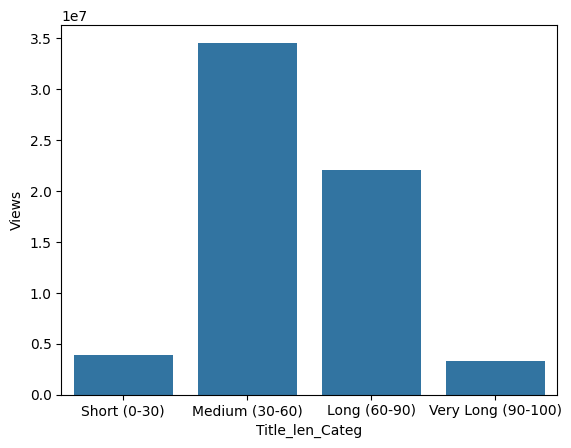

In [7]:
df["Title_Length"].min()
bins = [0,30,60,90,101]
labels = ["Short (0-30)", "Medium (30-60)", "Long (60-90)", "Very Long (90-100)"]
df["Title_len_Categ"] = pd.cut(df["Title_Length"], bins=bins, labels=labels)
summary_table = df.groupby("Title_len_Categ", observed=False)["Views"].sum()
summary_table = pd.DataFrame(summary_table).reset_index()
ax1 = sns.barplot(x="Title_len_Categ", y="Views", data=summary_table)